# Evaluation — transfer test on Daphnet

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rokhaya8/fall-detection-lstm/blob/main/notebooks/06_evaluation_daphnet.ipynb)

Part of [fall-detection-lstm](https://github.com/Rokhaya8/fall-detection-lstm). Paths are set by `BASE_DIR` in the first code cell — adapt it to your Google Drive.

In [ ]:
# 1. Montage du drive
from google.colab import drive
drive.mount('/content/drive')

# ── Dossier du projet dans Google Drive (à adapter si besoin) ──
import os
BASE_DIR = '/content/drive/MyDrive/Projet_Parkinson'
os.makedirs(f'{BASE_DIR}/Figures', exist_ok=True)


Mounted at /content/drive


X_daphnet : (35650, 200, 6)
y_daphnet : (35650,)
Modèle chargé 
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
Prédictions effectuées 

=== ÉVALUATION LSTM SUR DAPHNET (seuil=0.40) ===
Accuracy  : 0.295 (29.5%)
Precision : 0.119 (11.9%)
Recall    : 0.973 (97.3%)
F1-score  : 0.211 (21.1%)
FPR       : 0.778 (77.8%)
ROC-AUC   : 0.591
PR-AUC    : 0.109

Matrice de confusion :
  TP : 3370 | FP : 25045
  FN : 94 | TN : 7141


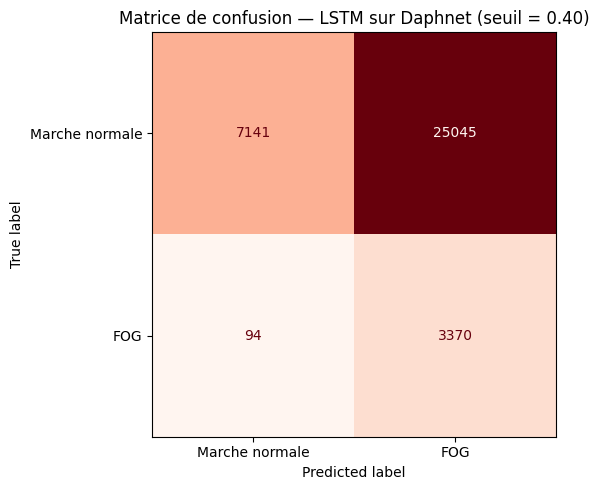

 Matrice sauvegardée sur Drive

Latence LSTM sur Daphnet : 84.232 ms/sample


In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# ===== 1. Chargement des données Daphnet =====
X_daphnet = np.load(f'{BASE_DIR}/Data_Preprocessed/Daphnet/X_daphnet_200Hz.npy')
y_daphnet = np.load(f'{BASE_DIR}/Data_Preprocessed/Daphnet/y_daphnet_200Hz.npy')

print(f"X_daphnet : {X_daphnet.shape}")
print(f"y_daphnet : {y_daphnet.shape}")

# ===== 2. Chargement du modèle =====
model = load_model(f'{BASE_DIR}/Models/LSTM_final.keras')
print("Modèle chargé ")

# ===== 3. Prédictions =====
y_pred_proba = model.predict(X_daphnet)
y_pred = (y_pred_proba >= 0.40).astype(int)
print("Prédictions effectuées ")

# ===== 4. Métriques =====
cm = confusion_matrix(y_daphnet, y_pred)
TN, FP, FN, TP = cm.ravel()

accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0
fpr       = FP / (FP + TN) if (FP + TN) > 0 else 0
roc_auc   = roc_auc_score(y_daphnet, y_pred_proba)
pr_auc    = average_precision_score(y_daphnet, y_pred_proba)

print("\n=== ÉVALUATION LSTM SUR DAPHNET (seuil=0.40) ===")
print(f"Accuracy  : {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Precision : {precision:.3f} ({precision*100:.1f}%)")
print(f"Recall    : {recall:.3f} ({recall*100:.1f}%)")
print(f"F1-score  : {f1:.3f} ({f1*100:.1f}%)")
print(f"FPR       : {fpr:.3f} ({fpr*100:.1f}%)")
print(f"ROC-AUC   : {roc_auc:.3f}")
print(f"PR-AUC    : {pr_auc:.3f}")
print(f"\nMatrice de confusion :")
print(f"  TP : {TP} | FP : {FP}")
print(f"  FN : {FN} | TN : {TN}")

# ===== 5. Matrice de confusion visuelle =====
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Marche normale', 'FOG']
)
disp.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Matrice de confusion — LSTM sur Daphnet (seuil = 0.40)')
plt.tight_layout()

plt.savefig(f'{BASE_DIR}/Figures/confusion_matrix_lstm_daphnet.png', dpi=150)
plt.show()
print(" Matrice sauvegardée sur Drive")

# ===== 6. Latence =====
sample = X_daphnet[0:1]
start = time.time()
for _ in range(100):
    model.predict(sample, verbose=0)
end = time.time()
latence = (end - start) / 100 * 1000
print(f"\nLatence LSTM sur Daphnet : {latence:.3f} ms/sample")